In [4]:
data

{'coluzziiPM': [0.008422459893048129, 0.9594919786096255],
 'Ngousso': [0.009625668449197862, 0.9582887700534759],
 'coluzziiCont': [0.011535087719298244, 0.9568859649122807],
 'gambiaeCont': [0.9582432432432433, 0.009324324324324324],
 'gambiaePM': [0.9549382716049382, 0.013315696649029983],
 'Kisumu': [0.9400000000000001, 0.027567567567567567]}

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import re
import pandas as pd

# Utility: convert 'rgb(r,g,b)' → '#rrggbb'
def rgb_to_hex(rgb: str) -> str:
    nums = list(map(int, re.findall(r"\d+", rgb)))
    return "#{:02x}{:02x}{:02x}".format(*nums)

# Define palette mapping, converting Plotly rgb → hex
TAXON_PALETTE = [rgb_to_hex(c) for c in px.colors.qualitative.Vivid]
TAXON_COLORS = {
    "gambiae": TAXON_PALETTE[1],
    "coluzzii": TAXON_PALETTE[0],
    "arabiensis": TAXON_PALETTE[2],
    "merus": TAXON_PALETTE[3],
    "melas": TAXON_PALETTE[4],
    "quadriannulatus": TAXON_PALETTE[5],
    "fontenillei": TAXON_PALETTE[6],
    "gcx1": TAXON_PALETTE[7],
    "gcx2": TAXON_PALETTE[8],
    "gcx3": TAXON_PALETTE[9],
    "gcx4": TAXON_PALETTE[10],
    "unassigned": "black",
}


df = pd.read_csv("/home/sanj/Projects/transcriptomics/rna-seq-bouake/old_results/variantAnalysis/ancestry/AIMs_summary.tsv", sep="\t")


In [16]:
data = {}
for index, row in df.iterrows():
    data[row.iloc[0]] = [row.iloc[1], row.iloc[2]]

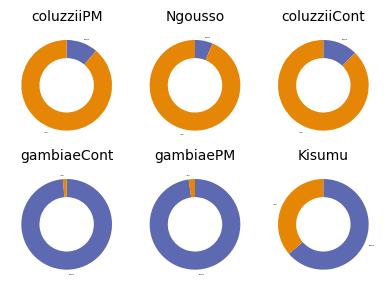

In [ ]:

labels = ["gambiae", "coluzzii"]
colors = [TAXON_COLORS["gambiae"], TAXON_COLORS["coluzzii"]]

# Plot
fig, axes = plt.subplots(2, 3, figsize=(4, 3))
axes = axes.flatten()

for ax, (sample, fractions) in zip(axes, data.items()):
    wedges, autotexts = ax.pie(
        fractions,
        labels=labels,
        # autopct="%1.1f%%",
        colors=colors,
        startangle=90,
        counterclock=False,
        textprops={"fontsize": 0},
        wedgeprops={"width": 0.4}  # donut thickness
    )
    ax.set_title(sample, fontsize=10)

plt.tight_layout()
plt.show()

### karyo donuts

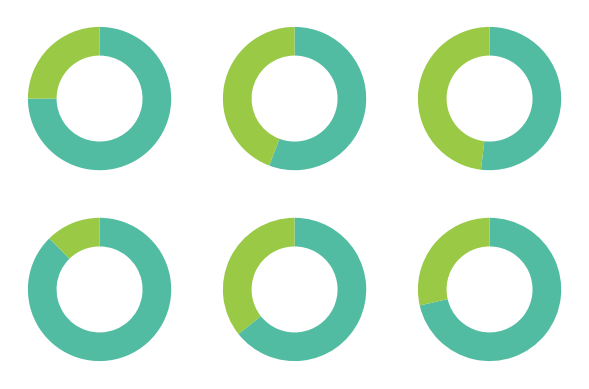

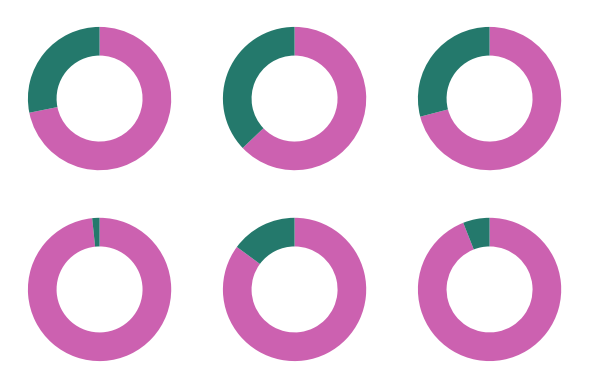

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import re

# Convert 'rgb(r,g,b)' → '#rrggbb'
def rgb_to_hex(rgb: str) -> str:
    nums = list(map(int, re.findall(r"\d+", rgb)))
    return "#{:02x}{:02x}{:02x}".format(*nums)

# TAXON colors converted to matplotlib format
TAXON_PALETTE = [rgb_to_hex(c) for c in px.colors.qualitative.Vivid]

KARYO_COLORS = {
    "2La_standard": TAXON_PALETTE[2],
    "2La_inverted": TAXON_PALETTE[3],
    "2Rb_standard": TAXON_PALETTE[4],
    "2Rb_inverted": TAXON_PALETTE[5],
}

# Explicit plotting order (clockwise arrangement)
plot_order = [
    "Kisumu", "gambiaeCont", "gambiaePM",
    "Ngousso", "coluzziiCont", "coluzziiPM"
]

for inv in ["2La", "2Rb"]:
    labels = ["standard", "inverted"]
    colors = [
        KARYO_COLORS[f"{inv}_standard"],
        KARYO_COLORS[f"{inv}_inverted"],
    ]

    # Read data
    df = pd.read_csv(
        f"../old_results/karyotype/{inv}.BouakePM.karyo.txt",
        sep="\t",
        index_col=0,
    )

    # Add fractions
    df = df.assign(inverted=df[f"{inv} frequency"]).assign(
        standard=1 - df[f"{inv} frequency"]
    )
    df = df.assign(
        treatment=df.sampleID.str.replace(r"\d+$", "", regex=True)
    )[["treatment", "standard", "inverted"]]
    df = df.groupby("treatment").mean().reset_index()
    df.to_csv(f"{inv}-freq.csv", sep="\t")

    # Collect into dictionary (treatment → fractions)
    data = {}
    for _, row in df.iterrows():
        data[row.iloc[0]] = [row.iloc[1], row.iloc[2]]

    # Make 2x3 subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(6, 4), facecolor="none")  # transparent bg
    axes = axes.flatten()

    # Follow fixed order
    for ax, sample in zip(axes, plot_order):
        if sample in data:
            fractions = data[sample]
            wedges, _ = ax.pie(
                fractions,
                labels=None,
                colors=colors,
                startangle=90,
                counterclock=False,
                textprops={"fontsize": 0},  # hide labels
                wedgeprops={"width": 0.4},
            )
        else:
            ax.axis("off")  # no data → hide axis

    plt.tight_layout()
    plt.savefig(f"{inv}-donuts.png", dpi=300, transparent=True)  # transparent saved output
    plt.show()